In [1]:
import pandas as pd


In [ ]:
df = pd.read_csv('Crime_Data_2001_2025.csv')

In [4]:

df.head(5)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,year,month,day
0,1324418,G004982,2001-01-03 00:35:00,049XX S STATE ST,0560,ASSAULT,SIMPLE,CHA APARTMENT,False,False,...,1177075.0,1872016.0,2001,08/17/2015 03:03:40 PM,41.804150,-87.626096,"(41.804149939, -87.62609605)",2001,1,3
1,1346339,G016050,2001-01-08 15:15:00,062XX S SEELEY AV,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,...,1163808.0,1863264.0,2001,08/17/2015 03:03:40 PM,41.780423,-87.674999,"(41.780422608, -87.67499891)",2001,1,8
2,1321327,G010569,2001-01-05 20:30:00,076XX S CICERO AV,0560,ASSAULT,SIMPLE,PARKING LOT/GARAGE(NON.RESID.),True,False,...,1145766.0,1853744.0,2001,08/17/2015 03:03:40 PM,41.754658,-87.741385,"(41.754658085, -87.741385006)",2001,1,5
3,1315116,G003953,2001-01-02 18:40:00,100XX W OHARE ST,0810,THEFT,OVER $500,AIRPORT/AIRCRAFT,True,False,...,1100635.0,1934208.0,2001,01/23/2019 04:13:37 PM,41.976200,-87.905312,"(41.976200173, -87.905312411)",2001,1,2
4,1314716,G006698,2001-01-03 22:10:00,041XX N MONTICELLO AV,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,1151283.0,1927037.0,2001,08/17/2015 03:03:40 PM,41.955677,-87.719246,"(41.955676954, -87.719245602)",2001,1,3


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467756 entries, 0 to 467755
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Date                  467756 non-null  datetime64[ns]
 1   Block                 467756 non-null  object        
 2   Primary Type          467756 non-null  object        
 3   Description           467756 non-null  object        
 4   Location Description  467756 non-null  object        
 5   Arrest                467756 non-null  bool          
 6   Domestic              467756 non-null  bool          
 7   Beat                  467756 non-null  int64         
 8   District              467756 non-null  float64       
 9   Ward                  467756 non-null  float64       
 10  Community Area        467756 non-null  float64       
 11  FBI Code              467756 non-null  object        
 12  X Coordinate          467756 non-null  float64       
 13 

In [63]:
#DC1
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)

In [64]:
# DC2
df['Primary Type'] = df['Primary Type'].replace(
    {'CRIM SEXUAL ASSAULT': 'CRIMINAL SEXUAL ASSAULT'}
)
df['Primary Type'] = df['Primary Type'].replace(
    {'OTHER NARCOTIC VIOLATION': 'NARCOTICS'}
)
df['Primary Type'] = df['Primary Type'].replace(
    {'HUMAN TRAFFICKING': 'KIDNAPPING'}
)
df['Primary Type'] = df['Primary Type'].replace(
    {'OBSCENITY': 'OTHER OFFENSE'}
)
df['Primary Type'] = df['Primary Type'].replace(
    {'PUBLIC INDECENCY': 'OTHER OFFENSE'}
)
df['Primary Type'] = df['Primary Type'].replace(
    {'RITUALISM': 'OTHER OFFENSE'}
)



In [65]:
#DC3
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['hour'] = df['Date'].dt.hour
df['weekday'] = df['Date'].dt.day_name()

In [66]:
#DC4
text_cols = ['Primary Type', 'Description', 'Location Description']
for col in text_cols:
    df[col] = df[col].str.strip().str.upper()

In [67]:
#DC5
df = df.drop(columns=['ID', 'Case Number', 'IUCR', 'Updated On', 'Location'], errors='ignore')

In [69]:
# Save cleaned dataset to a new CSV file
df.to_csv("chicago_crime_cleaned.csv", index=False)


In [ ]:
#EDA Analysis
df = pd.read_csv('chicago_crime_cleaned.csv')

<Axes: title={'center': 'Crimes per Year'}, xlabel='year'>

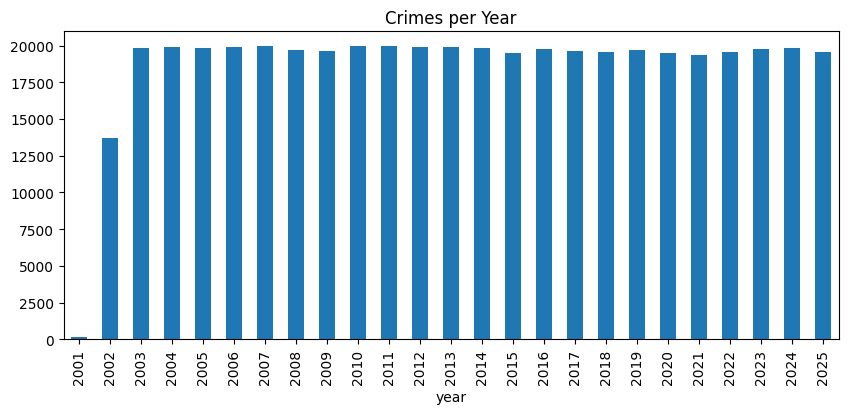

In [73]:
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Crimes per Year')


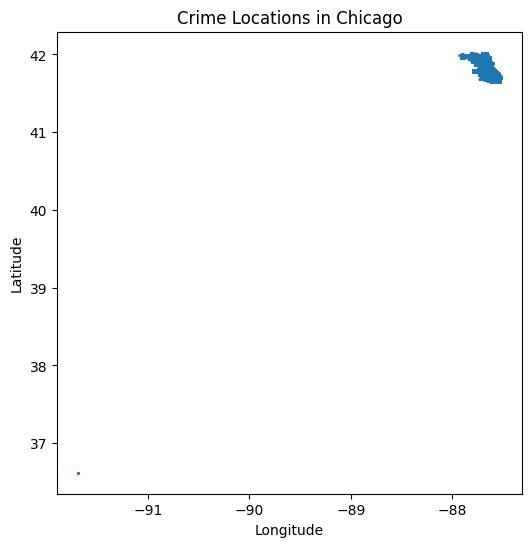

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df['Longitude'], df['Latitude'], s=1, alpha=0.5)
plt.title("Crime Locations in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


<Axes: title={'center': 'Top 10 Crime Types'}, ylabel='Primary Type'>

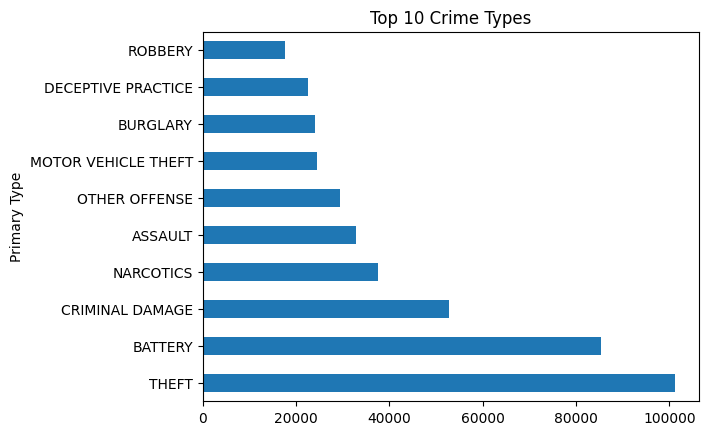

In [75]:
df['Primary Type'].value_counts().head(10).plot(kind='barh', title='Top 10 Crime Types')


In [76]:
pd.crosstab(df['Primary Type'], df['Arrest']).sort_values(by=True, ascending=False).head(10)


Arrest,False,True
Primary Type,,
NARCOTICS,277,37243
BATTERY,67263,18073
THEFT,91166,10044
CRIMINAL TRESPASS,4378,7917
ASSAULT,26661,6192
WEAPONS VIOLATION,2450,5805
OTHER OFFENSE,24134,5373
CRIMINAL DAMAGE,49538,3248
PROSTITUTION,19,3140


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467756 entries, 0 to 467755
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Date                  467756 non-null  object 
 1   Block                 467756 non-null  object 
 2   Primary Type          467756 non-null  object 
 3   Description           467756 non-null  object 
 4   Location Description  467756 non-null  object 
 5   Arrest                467756 non-null  bool   
 6   Domestic              467756 non-null  bool   
 7   Beat                  467756 non-null  int64  
 8   District              467756 non-null  float64
 9   Ward                  467756 non-null  float64
 10  Community Area        467756 non-null  float64
 11  FBI Code              467756 non-null  object 
 12  X Coordinate          467756 non-null  float64
 13  Y Coordinate          467756 non-null  float64
 14  Year                  467756 non-null  int64  
 15  